In [184]:
# importing data and libraries
import torch
import matplotlib.pyplot as plt
import numpy as np
words = open(r"Indian_Names.txt", 'r').read().lower().splitlines()

In [185]:
indiv = sorted(set((''.join(words))))
indiv
# made mistake by set-ing twice here. caused N matrix havoc

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [186]:
# 2 converters
stoi = {s:i+1 for i, s in enumerate(indiv)}
stoi['.'] = 0
itos = {s:i for i, s in stoi.items()}
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [187]:
# initializing the conversion matrix
N = torch.zeros((27, 27), dtype=torch.int32)

In [188]:
for w in words:
    chrs = ['.'] + list(w) + ['.']
    # print(chrs)
    for ch1, ch2 in zip(chrs, chrs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1

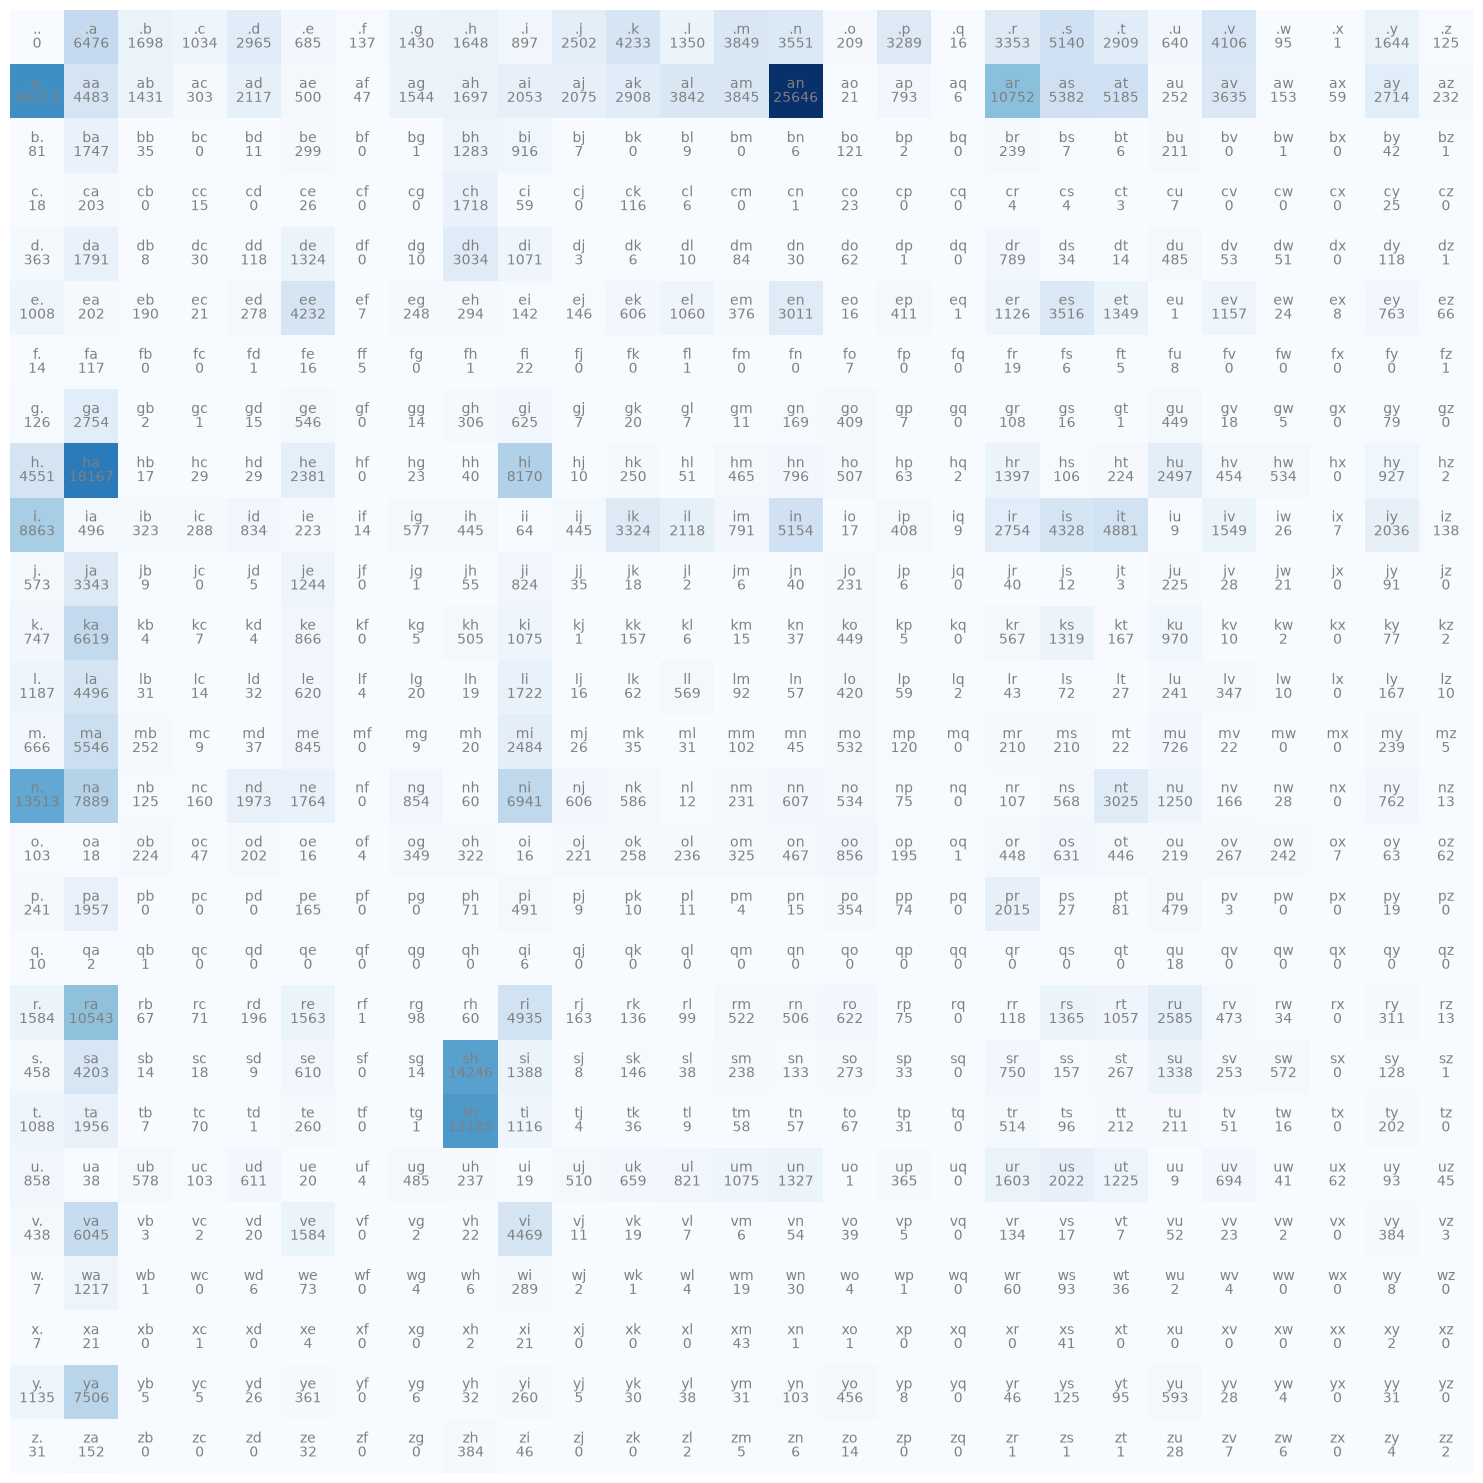

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(19,19))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color= 'gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color= 'gray')
plt.axis('off');

In [190]:
P = (N+1).float()
P /= P.sum(1,keepdims=True)
print('Created Probablity matrix as well!')
print('='*34)
print('Now onto fixating on Loss and creating the random seed for weights and stuff')

Created Probablity matrix as well!
Now onto fixating on Loss and creating the random seed for weights and stuff


In [191]:
g = torch.Generator().manual_seed(47347) # not ai, ab mai hi sikh gaya hu 42 😭
for i in range(25):
    idx = 0
    out = []
    while True:
        p = P[idx]
        idx = torch.multinomial(p, num_samples = 1, replacement = True, generator=g).item() # item() and num_samples killed the f' outta me
        if idx == 0:
            break
        out.append(itos[idx])
    print(''.join(out)) # oh yeah!

amaishinakani
ventarininvaranigira
siseeela
eam
kathithiki
ksa
a
arit
nishanayanathumanin
ehal
sh
rathithagyudavi
saishvenmannman
charisuxmasana
thveenthy
ashaakajankajath
chkapasha
larithwa
thaaniksisiyadveenivish
ashinthwmugajarthugokanasokaa
lanajignarelpantrajjaya
alanikameesumivan
me
thagn
bhanimali


In [192]:
# pre-forward pass stuff
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])
xs = torch.tensor(xs)
ys = torch.tensor(ys)

W = torch.randn((27, 27), generator=g, requires_grad=True)
import torch.nn.functional as F

In [193]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

# it was copied from the video the loss equation. but will study how was it made.
loss = -probs[torch.arange(488074), ys].log().mean()
loss

tensor(3.7761, grad_fn=<NegBackward0>)

In [194]:
# loss bkl!
loss.backward()
W.data += -0.1 * W.grad

In [195]:
# now packing all it in a for loop
for i in range(1000):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)

    # loss calc
    loss = -probs[torch.arange(488074), ys].log().mean()

    if i%100 == 0:
        print(f'Epoch {i+1}')
        print('Loss: ', loss.item())
    
    # backpropogation & updation
    loss.backward()
    W.data += -0.1 * W.grad


Epoch 1
Loss:  3.7746078968048096
Epoch 101
Loss:  2.7034268379211426
Epoch 201
Loss:  2.7851948738098145
Epoch 301
Loss:  2.860898971557617
Epoch 401
Loss:  2.9546542167663574


KeyboardInterrupt: 

In [198]:
# facing some kinda plateu in loss space ig

In [197]:
# now packing all it in a for loop
for i in range(10000):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)

    # loss calc
    loss = -probs[torch.arange(len(xs)), ys].log().mean() + 0.01*(W**2).mean() # REGULARIZATION (lasso)

    if i%100 == 0:
        print(f'Epoch {i+1}')
        print('Loss: ', loss.item())
    
    # backpropogation & updation
    W.grad = None
    loss.backward()
    W.data += -0.1 * W.grad

Epoch 1
Loss:  2.985299587249756
Epoch 101
Loss:  2.9740419387817383
Epoch 201
Loss:  2.96370267868042
Epoch 301
Loss:  2.954124689102173
Epoch 401
Loss:  2.945190668106079
Epoch 501
Loss:  2.9368107318878174
Epoch 601
Loss:  2.9289159774780273
Epoch 701
Loss:  2.921450138092041
Epoch 801
Loss:  2.914367437362671
Epoch 901
Loss:  2.9076311588287354
Epoch 1001
Loss:  2.9012086391448975
Epoch 1101
Loss:  2.8950729370117188
Epoch 1201
Loss:  2.8892006874084473
Epoch 1301
Loss:  2.883570432662964
Epoch 1401
Loss:  2.878164052963257
Epoch 1501
Loss:  2.872965097427368
Epoch 1601
Loss:  2.8679583072662354
Epoch 1701
Loss:  2.863130807876587
Epoch 1801
Loss:  2.8584694862365723
Epoch 1901
Loss:  2.8539652824401855
Epoch 2001
Loss:  2.84960675239563
Epoch 2101
Loss:  2.845385789871216
Epoch 2201
Loss:  2.841294288635254
Epoch 2301
Loss:  2.837324380874634
Epoch 2401
Loss:  2.8334696292877197
Epoch 2501
Loss:  2.8297243118286133
Epoch 2601
Loss:  2.826082706451416
Epoch 2701
Loss:  2.8225398063

In [200]:
for i in range(10):
    idx = 0
    out = []
    while True:
        xenc = F.one_hot(torch.tensor([idx]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)
        idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        if idx == 0:
            break
        out.append(itos[idx])
    print(''.join(out))

swan
hurarithulikaswavel
dranarmavikadan
ma
radar
gamavek
rishar
vimajeerala
nyeeka
sathin
